# 08 · Memory, Part 1 — The Store and the Retrieval Bottleneck

Notebook 05 showed the context window is **bounded and quadratic**; Notebook 07's agent had only an ephemeral scratchpad. To remember *more than fits in context*, a model needs **external memory** — a store you search and inject the relevant pieces of. That shifts the whole problem onto one question: **can you retrieve the right memory?**

This notebook builds that machinery from scratch and — in the spirit of the lab — *measures* it instead of trusting folklore:

1. **A `MemoryStore`** of plain text records, plus two **confusable clusters** (near-identical episodes that differ only by an ID — the realistic hard case).
2. **Two retrievers**: dense (embeddings + cosine) and lexical (BM25), then a **hybrid** (reciprocal rank fusion).
3. **Retrieval as a measured variable** — recall@k and MRR on labeled probes split by query type. The result is a useful surprise about what actually helps.
4. **The payoff** — an LLM *hallucinates* a fact it can't know, then answers correctly once the retrieved memory is in context (and is misled when the retrieval is wrong).

Reusable code: `llmlab/memory/{store,corpus}.py`, `llmlab/retrieval/{embeddings,retrievers,metrics}.py`; tests: `tests/test_retrieval.py`.

In [ ]:
import sys
from pathlib import Path

LLM_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(LLM_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_DIR))

import json
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_VERBOSITY"] = "error"
import transformers
transformers.logging.set_verbosity_error()
import huggingface_hub
huggingface_hub.logging.set_verbosity_error()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from llmlab import config
from llmlab.models.local_model import LocalModel, SamplingConfig
from llmlab.memory.corpus import SAMPLE_MEMORIES, RETRIEVAL_PROBES, build_sample_store
from llmlab.retrieval.embeddings import Embedder
from llmlab.retrieval.retrievers import DenseRetriever, BM25Retriever, HybridRetriever
from llmlab.retrieval.metrics import evaluate_retriever

config.configure_caches()
config.ensure_dirs()
config.seed_everything(0)


def show_hits(label, hits, gold=None):
    marks = []
    for h in hits:
        flag = "*" if (gold and h.id in gold) else " "
        marks.append(f"{flag}{h.id}({h.score:.2f})")
    print(f"  {label:7s}: " + "  ".join(marks))


print("device:", config.get_device(), "| memories:", len(SAMPLE_MEMORIES),
      "| probes:", len(RETRIEVAL_PROBES))

device: mps | memories: 32 | probes: 16


## 1. Three kinds of memory

"Memory" in an LLM system is not one thing. It lives in three very different places:

| | where | capacity | updatable? | failure mode |
|---|---|---|---|---|
| **Parametric** | model weights | enormous, but *frozen* | no (only by training) | confidently *hallucinates* rare/new facts |
| **Working** | the prompt / context window | small, **O(n²)** attention (NB 05) | yes, per turn | forgotten after the turn; runs out of room |
| **External** | a store you search | unbounded, persistent | yes, anytime | only as good as **retrieval** |

External memory is how you remember more than fits in context — but it moves the hard problem from *"fit it in the window"* to *"retrieve the right thing"*. So the rest of this notebook is mostly about retrieval, because **retrieval quality is the bottleneck** for everything an agent remembers.

In [ ]:
store = build_sample_store()
print(f"{len(store)} memories. A few:")
for r in store.all()[:4]:
    print(f"  [{r.id}] ({r.kind}) {r.text}")

# The hard case: a 'confusable cluster' — episodic memories that are *identical*
# except for an opaque ID. Only the exact token tells them apart.
print("\nConfusable cluster (incidents) — identical text, different code:")
for r in store.all():
    if r.text.startswith("Incident INC-"):
        print(f"  [{r.id}] {r.text}")

32 memories. A few:
  [m01] (semantic) The user prefers dark mode in every editor and terminal.
  [m02] (semantic) For systems programming the user's language of choice is Rust.
  [m03] (episodic) On 2026-03-02 the user deployed the billing service to production.
  [m04] (semantic) The staging database password lives in the vault under key DB_STAGING_PW.

Confusable cluster (incidents) — identical text, different code:
  [m20] Incident INC-2055 was caused by a memory leak in the websocket handler.
  [m25] Incident INC-3071 was caused by a memory leak in the websocket handler.
  [m26] Incident INC-4188 was caused by a memory leak in the websocket handler.
  [m27] Incident INC-5219 was caused by a memory leak in the websocket handler.
  [m28] Incident INC-6634 was caused by a memory leak in the websocket handler.


## 2. Two ways to find a memory

- **Dense** (`DenseRetriever`): embed every memory into a unit vector with a sentence-transformer (`all-MiniLM-L6-v2`, 384-d), embed the query the same way, rank by **cosine similarity** (just a dot product of normalised vectors — no magic, and exact; FAISS would only matter past ~10⁴ items). Captures *meaning*.
- **Lexical** (`BM25Retriever`): rank by **BM25**, a TF-IDF-style score over shared tokens. Captures *exact words*, and rewards rare ones (a unique ID dominates the score).

Folklore says dense wins on paraphrase and lexical wins on exact terms. Let's look at one of each before measuring (a `*` marks the gold memory).

In [ ]:
embedder = Embedder()               # downloads all-MiniLM-L6-v2 once, then cached
dense = DenseRetriever(store, embedder)
bm25 = BM25Retriever(store)
print("embedding dim:", embedder.dim)

q_para = "How do I like my morning beverage prepared?"   # gold m16 (coffee), zero shared words
print(f"\nPARAPHRASE  {q_para!r}  (gold m16)")
show_hits("dense", dense.search(q_para, 3), {"m16"})
show_hits("bm25", bm25.search(q_para, 3), {"m16"})

q_id = "Which incident was INC-2055?"                     # gold m20, among 5 identical-text siblings
print(f"\nEXACT-ID    {q_id!r}  (gold m20)")
show_hits("dense", dense.search(q_id, 3), {"m20"})
show_hits("bm25", bm25.search(q_id, 3), {"m20"})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding dim: 384

PARAPHRASE  'How do I like my morning beverage prepared?'  (gold m16)
  dense  : *m16(0.31)   m09(0.22)   m06(0.13)
  bm25   :  m01(0.00)   m30(0.00)   m29(0.00)

EXACT-ID    'Which incident was INC-2055?'  (gold m20)
  dense  : *m20(0.48)   m28(0.40)   m27(0.39)
  bm25   : *m20(7.49)   m28(4.60)   m27(4.60)


## 3. What dense retrieval "sees"

Why does dense find the coffee note from "morning beverage" with no shared words? Because the embedder maps *meaning* to nearby vectors. The heatmap below is the cosine similarity between five paraphrase queries and a handful of memories — the bright diagonal is the semantic match landing on its target despite different vocabulary.

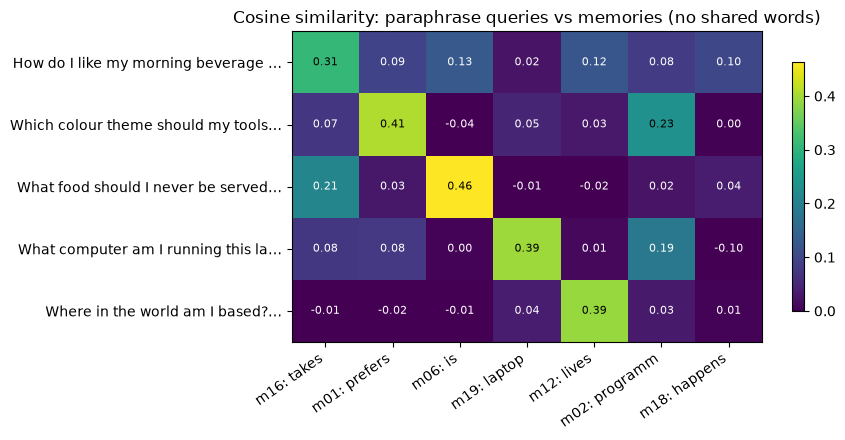

In [ ]:
queries = [
    "How do I like my morning beverage prepared?",
    "Which colour theme should my tools use?",
    "What food should I never be served at lunch?",
    "What computer am I running this lab on?",
    "Where in the world am I based?",
]
mem_ids = ["m16", "m01", "m06", "m19", "m12", "m02", "m18"]  # 5 targets + 2 distractors
mems = [store.get(i) for i in mem_ids]

Q = embedder.encode(queries)
M = embedder.encode([m.text for m in mems])
sim = Q @ M.T  # both normalised -> cosine

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(sim, cmap="viridis", aspect="auto", vmin=0, vmax=sim.max())
ax.set_xticks(range(len(mems)))
ax.set_xticklabels([f"{m.id}: {m.text.split()[2][:8]}" for m in mems], rotation=35, ha="right")
ax.set_yticks(range(len(queries)))
ax.set_yticklabels([q[:34] + "…" for q in queries])
for i in range(len(queries)):
    for j in range(len(mems)):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center",
                color="white" if sim[i, j] < 0.5 * sim.max() else "black", fontsize=8)
ax.set_title("Cosine similarity: paraphrase queries vs memories (no shared words)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Measure it — recall@k and MRR

Anecdotes aren't evidence. The probe set has a gold memory per query, labeled by type:

- **paraphrase** — semantic intent, disjoint vocabulary,
- **exact-term** — disambiguate a near-identical memory by its ID,
- **mixed** — a semantic question that also contains a distinctive term.

Two metrics: **recall@k** (is the right memory in the top *k*?) and **MRR** (how *high* is it ranked?). We report at k=3, overall and per category.

In [ ]:
K = 3


def row(retriever, name=None):
    rep = evaluate_retriever(retriever, RETRIEVAL_PROBES, k=K)
    cats = rep.recall_by_category()
    return {
        "retriever": name or retriever.name,
        f"recall@{K}": rep.recall_at_k,
        "MRR": rep.mrr,
        "paraphrase": cats["paraphrase"],
        "exact-term": cats["exact-term"],
        "mixed": cats["mixed"],
    }


table = pd.DataFrame([row(dense), row(bm25)])
print(table.round(3).to_string(index=False))

retriever  recall@3   MRR  paraphrase  exact-term  mixed
    dense     1.000 1.000         1.0         1.0    1.0
     bm25     0.812 0.812         0.5         1.0    1.0


## 5. Is hybrid better? Not for free.

The table should already be surprising: a strong modern embedder is *hard to beat*. It even disambiguates the identical-text incidents, because the ID is in the query and survives sub-word embedding. BM25's only systematic weakness is **paraphrase** — the vocabulary gap.

The reflex is to reach for **hybrid** search. **Reciprocal Rank Fusion (RRF)** scores each memory by the sum over retrievers of `1 / (rrf_k + rank)` — rank-based, so it ignores the retrievers' incompatible score scales. But fusion is not free:

- **Naive RRF** rewards a memory just for *appearing* in a retriever's candidate pool — so BM25's zero-overlap fillers get fused credit and can drag a correct dense hit down.
- **Gating** (drop non-positive hits before fusing) fixes that pollution.

We ablate both. Watch whether hybrid actually beats the best single retriever **on this store** — the honest answer is the lesson.

     retriever  recall@3   MRR  paraphrase  exact-term  mixed
         dense     1.000 1.000       1.000         1.0    1.0
          bm25     0.812 0.812       0.500         1.0    1.0
hybrid (naive)     0.875 0.844       0.667         1.0    1.0
hybrid (gated)     0.875 0.875       0.667         1.0    1.0


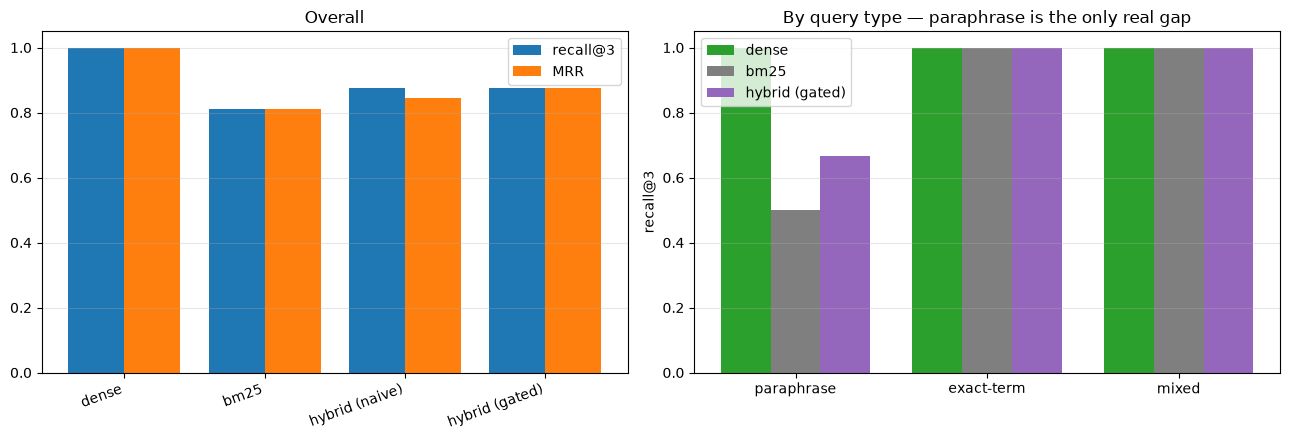

In [ ]:
hybrid_naive = HybridRetriever(dense, bm25, method="rrf", gate=False)
hybrid_gate = HybridRetriever(dense, bm25, method="rrf", gate=True)

table = pd.DataFrame([
    row(dense, "dense"),
    row(bm25, "bm25"),
    row(hybrid_naive, "hybrid (naive)"),
    row(hybrid_gate, "hybrid (gated)"),
])
print(table.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# left: overall recall@3 and MRR
names = table["retriever"].tolist()
xx = np.arange(len(names))
axes[0].bar(xx - 0.2, table[f"recall@{K}"], 0.4, label=f"recall@{K}", color="tab:blue")
axes[0].bar(xx + 0.2, table["MRR"], 0.4, label="MRR", color="tab:orange")
axes[0].set_xticks(xx); axes[0].set_xticklabels(names, rotation=20, ha="right")
axes[0].set_ylim(0, 1.05); axes[0].set_title("Overall"); axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")
# right: recall@3 by category for dense / bm25 / hybrid(gated)
cats = ["paraphrase", "exact-term", "mixed"]
sub = table.set_index("retriever").loc[["dense", "bm25", "hybrid (gated)"], cats]
cx = np.arange(len(cats)); w = 0.26
for i, (rname, color) in enumerate(zip(sub.index, ["tab:green", "tab:gray", "tab:purple"])):
    axes[1].bar(cx + (i - 1) * w, sub.loc[rname], w, label=rname, color=color)
axes[1].set_xticks(cx); axes[1].set_xticklabels(cats)
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel(f"recall@{K}")
axes[1].set_title("By query type — paraphrase is the only real gap"); axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 6. Closing the loop — retrieval becomes working memory

Retrieval only matters if it changes what the model *says*. The store holds a fictional fact the model cannot possibly know from its weights (`INC-2055`). Three conditions:

1. **No memory** — the model answers from parametric memory alone, and *hallucinates*.
2. **Correct retrieved memory** in context — it answers correctly.
3. **A wrong memory** injected — it confidently repeats the wrong fact.

This is the whole thesis in three prompts: external memory makes a small model reliable about specifics — **exactly as far as retrieval is correct**. (Wiring retrieval *into the agent loop* is Notebook 09.)

In [ ]:
lm = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32", attn_implementation="sdpa")


def answer(question, notes=None, max_new_tokens=80):
    if notes:
        sysmsg = ("Answer the question using ONLY the notes below. "
                  "If the notes do not contain the answer, reply exactly: I don't know.")
        user = "Notes:\n" + "\n".join(f"- {n}" for n in notes) + f"\n\nQuestion: {question}"
    else:
        sysmsg = "Answer the question concisely."
        user = question
    msgs = [{"role": "system", "content": sysmsg}, {"role": "user", "content": user}]
    return lm.generate(msgs, SamplingConfig(max_new_tokens=max_new_tokens)).text.strip()


Q = "What caused incident INC-2055?"
retrieved = dense.search(Q, k=1)[0]
wrong = "Incident INC-2055 was caused by a DNS misconfiguration in the load balancer."

print("Q:", Q)
print("\n(a) NO MEMORY (weights only) :", answer(Q).replace("\n", " "))
print(f"\n(b) RETRIEVED  [{retrieved.id}] : {answer(Q, [retrieved.text])}")
print(f"     (retrieved memory: {retrieved.text!r})")
print(f"\n(c) WRONG MEMORY injected     : {answer(Q, [wrong])}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Q: What caused incident INC-2055?



(a) NO MEMORY (weights only) : Incident INC-2055 was caused by a malfunction in the control system of a chemical plant, leading to a significant safety hazard.



(b) RETRIEVED  [m20] : A memory leak in the websocket handler was the cause of incident INC-2055.
     (retrieved memory: 'Incident INC-2055 was caused by a memory leak in the websocket handler.')



(c) WRONG MEMORY injected     : DNS misconfiguration in the load balancer was the cause of incident INC-2055.


## 7. What this means — and the research thread

What the measurements actually showed (not the folklore):

- **A strong embedder is a formidable default.** An 80 MB MiniLM got perfect recall@3 across every query type on this store — *including* disambiguating identical-text incidents by their ID, because the ID is in the query and survives sub-word embedding. Dense-first is the right starting point.
- **Lexical's real weakness is the vocabulary gap.** BM25 simply cannot match "morning beverage" to "coffee". That — not exact-term lookup — is where it loses.
- **Hybrid is an empirical question, not a default.** Fusing a weaker retriever *dragged the stronger one down* here; gating zero-overlap hits recovered ranking (MRR) but not recall. Reach for hybrid when the retrievers are genuinely complementary, and **measure** it.
- **Retrieval quality is the bottleneck.** The LLM was reliable *exactly as far as* retrieval was correct — and parroted a wrong injected memory just as confidently. Garbage in, garbage out.

**Caveats this tiny store hides:** at 10⁴–10⁶ memories dense recall drops and BM25/hybrid (and a re-ranker) earn their keep; domain jargon or codes an embedder never saw break dense; quantized embedders are weaker. Scale changes the answer — which is why the harness matters more than today's numbers.

**The open questions — the actual research (Notebooks 09–10+):**

- **What should an agent *store*?** Every turn? Only "surprising" facts? (write policy)
- **What to *forget* or *merge*?** recency/usage decay, deduping the confusable clusters.
- **Compression** — summarise many episodes into one semantic memory without losing the disambiguating detail.
- **Contradiction** — two memories disagree; which wins?
- **Does memory actually help end-to-end?** Notebook 10 turns "retrieval helps" into an accuracy/cost delta on a task — the same way we measured reasoning and tools.

**Next — Notebook 09:** give the Notebook 07 agent a `retrieve` tool over this store, and let it decide *when* to consult memory.

In [ ]:
summary = {
    "embedder": embedder.model_id,
    "llm": lm.model_id,
    "device": lm.device,
    "n_memories": len(store),
    "n_probes": len(RETRIEVAL_PROBES),
    "k": K,
    "retrievers": {
        r["retriever"]: {
            "recall_at_k": round(r[f"recall@{K}"], 3),
            "mrr": round(r["MRR"], 3),
            "recall_paraphrase": round(r["paraphrase"], 3),
            "recall_exact_term": round(r["exact-term"], 3),
            "recall_mixed": round(r["mixed"], 3),
        }
        for r in table.to_dict("records")
    },
}
path = config.RESULTS_DIR / "08_memory_store_basics.json"
path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nwrote", path)

{
  "embedder": "sentence-transformers/all-MiniLM-L6-v2",
  "llm": "Qwen/Qwen2.5-0.5B-Instruct",
  "device": "mps",
  "n_memories": 32,
  "n_probes": 16,
  "k": 3,
  "retrievers": {
    "dense": {
      "recall_at_k": 1.0,
      "mrr": 1.0,
      "recall_paraphrase": 1.0,
      "recall_exact_term": 1.0,
      "recall_mixed": 1.0
    },
    "bm25": {
      "recall_at_k": 0.812,
      "mrr": 0.812,
      "recall_paraphrase": 0.5,
      "recall_exact_term": 1.0,
      "recall_mixed": 1.0
    },
    "hybrid (naive)": {
      "recall_at_k": 0.875,
      "mrr": 0.844,
      "recall_paraphrase": 0.667,
      "recall_exact_term": 1.0,
      "recall_mixed": 1.0
    },
    "hybrid (gated)": {
      "recall_at_k": 0.875,
      "mrr": 0.875,
      "recall_paraphrase": 0.667,
      "recall_exact_term": 1.0,
      "recall_mixed": 1.0
    }
  }
}

wrote /Users/iali/workplace/projects/personal/ml-notes/docs/LLM/results/08_memory_store_basics.json
